# Alfido Tech Revenue Optimization Analysis

## Business Question
Which regions, product categories, and time periods contribute the most to revenue, and what strategies can improve business performance?

## Objective
The objective of this project is to analyze sales data and identify key revenue drivers, customer trends, and business opportunities. The insights generated will help Alfido Tech improve decision-making and optimize revenue growth.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!unzip "superstore_final_dataset (1).csv.zip"

Archive:  superstore_final_dataset (1).csv.zip
  inflating: superstore_final_dataset (1).csv  


In [3]:
df = pd.read_csv("superstore_final_dataset (1).csv", encoding='latin1')
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


## Dataset Overview

- Dataset: Superstore Sales Dataset
- Records: 9800
- Features: 20
- Data Type: Sales Transactions
- Analysis Tool: Python (Pandas, Matplotlib)

In [4]:
df.drop_duplicates(inplace=True)

df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month

print(df.shape)

(9800, 20)


## KPI Analysis

The following KPIs are used to evaluate overall business performance:
- Total Revenue
- Total Orders
- Total Customers
- Average Order Value

In [5]:
total_revenue = df['Sales'].sum()
total_orders = df['Order_ID'].nunique()
total_customers = df['Customer_ID'].nunique()
average_order_value = df.groupby('Order_ID')['Sales'].sum().mean()

print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(average_order_value,2))

Total Revenue: 2261536.78
Total Orders: 4922
Total Customers: 793
Average Order Value: 459.48


### Key Insight

The business generated $2.26 million

in revenue from 4,922 orders placed by 793 customers. The average order value was $459.48, indicating strong customer spending behavior.

## Regional Performance Analysis

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


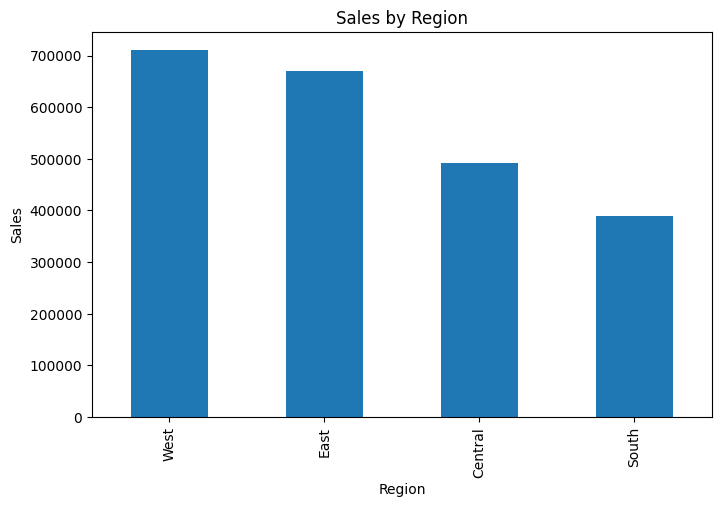

In [6]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

region_sales.plot(kind='bar', figsize=(8,5))
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

### Observation

The West region generated the highest revenue, followed by the East region. The South region recorded the lowest sales. This suggests that marketing and business expansion efforts should focus on high-performing regions while improving performance in weaker markets.

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


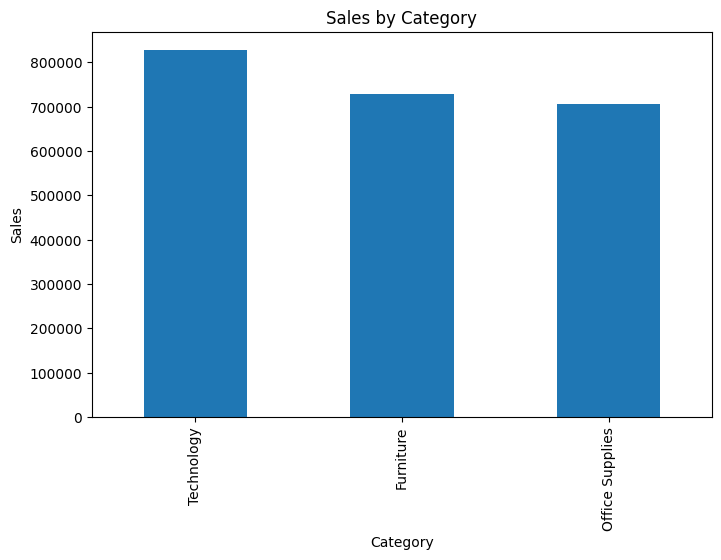

In [7]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

category_sales.plot(kind='bar', figsize=(8,5))
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

### Observation

Technology is the highest-performing category, generating the largest share of revenue. This indicates strong customer demand for technology-related products.

Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


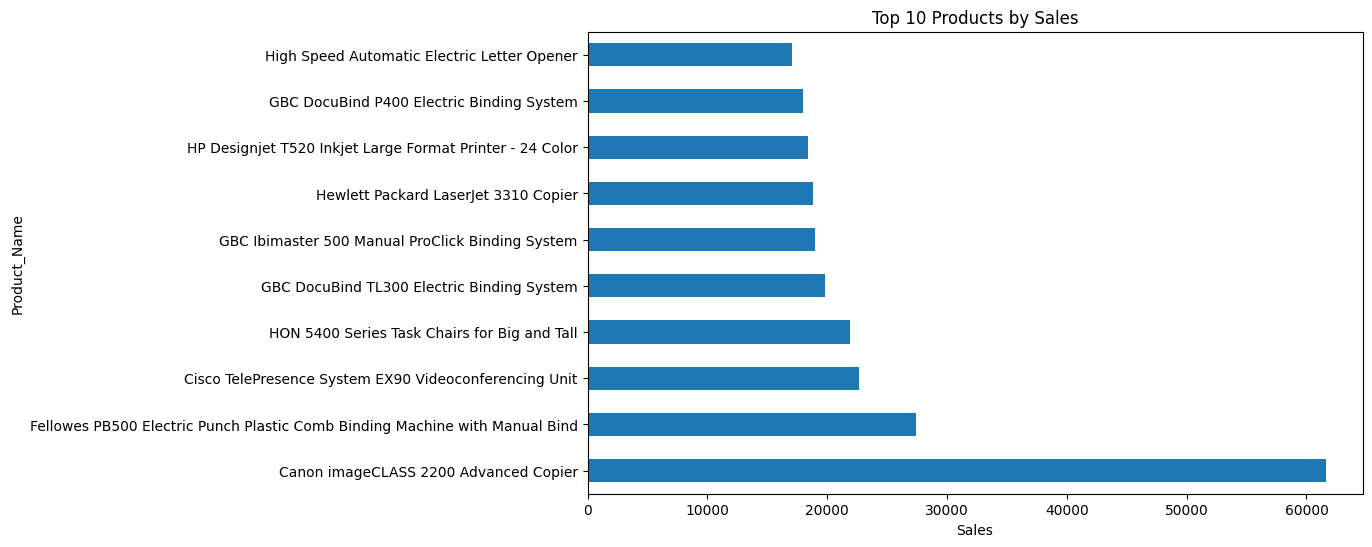

In [8]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

top_products.plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.show()

### Observation

The Canon imageCLASS 2200 Advanced Copier is the highest revenue-generating product. Several technology and office equipment products dominate the top-selling list.

Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64


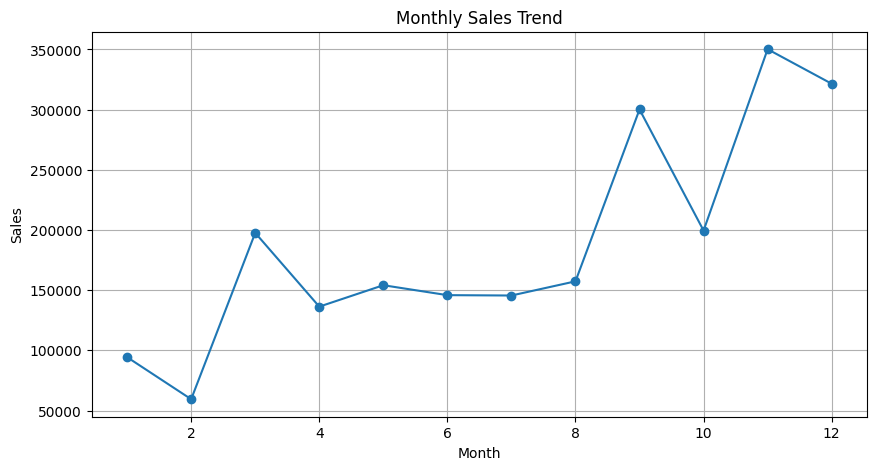

In [9]:
monthly_sales = df.groupby('Month')['Sales'].sum()

print(monthly_sales)

monthly_sales.plot(marker='o', figsize=(10,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

### Observation

Sales peak during September, November, and December, indicating strong seasonal demand during the final quarter of the year.

# Key Findings

1. Total revenue generated was $2,261,536.78.

2. A total of 4,922 orders were placed by 793 unique customers.
3. The average order value was $459.48.
4. The West region generated the highest sales revenue.
5. Technology was the best-performing product category.
6. The Canon imageCLASS 2200 Advanced Copier was the highest-selling product.
7. Sales peaked during September, November, and December, indicating strong seasonal demand.

# Business Recommendations

1. Increase marketing investment in the West and East regions to maximize revenue growth.
2. Expand inventory and promotional activities for Technology products.
3. Focus on top-selling products to improve overall profitability.
4. Launch targeted campaigns during September–December to capitalize on seasonal demand.
5. Develop strategies to improve sales performance in lower-performing regions.

# Conclusion

This project analyzed sales data to identify important business trends and revenue drivers. The analysis revealed that the West region, Technology category, and several high-value products contributed significantly to overall revenue. Seasonal trends showed strong sales growth during the final quarter of the year. The insights and recommendations provided can help Alfido Tech make data-driven decisions, improve resource allocation, and optimize revenue growth strategies.